<a href="https://colab.research.google.com/github/youssef-Araby/intro-to-ai/blob/main/Lab1_DataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: NumPy, pandas, and Matplotlib

In AI, we usually need to:

1. store data;
2. inspect and clean it;
3. perform calculations; and
4. visualize the results.

This lab introduces three Python libraries that help us do these tasks.

A **library** is a collection of ready-made Python code, including functions and data structures. The `import` command loads a library so we can use it. The word after `as` gives it a shorter name, such as `np`, `pd`, or `plt`.

## Learning outcomes

By the end of the lab, you should be able to:

- import NumPy, pandas, and Matplotlib;
- create a NumPy array and explain why arrays are useful;
- create and inspect a pandas DataFrame;
- load a CSV file with pandas;
- select, filter, clean, and group data;
- create line, bar, histogram, and scatter plots; and
- apply these tools to the Titanic dataset.


## Before you start

You should already know basic Python variables, lists, conditions, loops, and functions.

This notebook is designed for **Google Colab** and requires an internet connection to download the Titanic dataset. Run the cells from top to bottom. If you want to repeat the whole lab, restart the Colab session and then run all cells again.

Approximate hands-on time:

| Part | Time |
|---|---:|
| NumPy | 30 minutes |
| pandas | 40 minutes |
| Matplotlib | 35 minutes |
| Titanic dataset | 65 minutes |
| Practice and discussion | 10 minutes |


---

# Part 1: NumPy

## What is NumPy?

**NumPy** stands for Numerical Python. It is used to store numbers in arrays and perform calculations on many values at the same time.

NumPy is useful in AI because datasets are often represented as tables of numbers:

- each row represents one example;
- each column represents one feature; and
- AI algorithms perform many mathematical operations on these values.

We normally import NumPy using the short name `np`.


In [1]:
import numpy as np

# A normal Python list
numbers_list = [10, 20, 30, 40]

# Convert the list to a NumPy array
numbers_array = np.array(numbers_list)

print("Python list:", numbers_list)
print("NumPy array:", numbers_array)
print("Type of the list:", type(numbers_list))
print("Type of the array:", type(numbers_array))


Python list: [10, 20, 30, 40]
NumPy array: [10 20 30 40]
Type of the list: <class 'list'>
Type of the array: <class 'numpy.ndarray'>


## Why convert a list to a NumPy array?

NumPy arrays make numerical operations easier. Notice the difference between multiplying a Python list and multiplying a NumPy array.


In [2]:
print("Python list multiplied by 2:", numbers_list * 2)
print("NumPy array multiplied by 2:", numbers_array * 2)


Python list multiplied by 2: [10, 20, 30, 40, 10, 20, 30, 40]
NumPy array multiplied by 2: [20 40 60 80]


The Python list is repeated. The NumPy array multiplies every value.

Arrays also provide information that is useful when working with datasets:

- `shape`: the size of each dimension;
- `ndim`: the number of dimensions;
- `size`: the total number of values; and
- `dtype`: the type of the stored values.


In [3]:
print("Shape:", numbers_array.shape)
print("Number of dimensions:", numbers_array.ndim)
print("Number of values:", numbers_array.size)
print("Data type:", numbers_array.dtype)

print("First value:", numbers_array[0])
print("First three values:", numbers_array[0:3])


Shape: (4,)
Number of dimensions: 1
Number of values: 4
Data type: int64
First value: 10
First three values: [10 20 30]


## Common NumPy functions used in this lab

| Function | Purpose |
|---|---|
| `np.array()` | Convert a list into an array |
| `np.arange()` | Create a sequence of numbers |
| `np.zeros()` | Create an array filled with zeros |
| `np.sum()` | Find the total |
| `np.mean()` | Find the average |
| `np.min()` / `np.max()` | Find the smallest or largest value |
| `np.reshape()` | Change the shape of an array |
| `np.where()` | Choose values based on a condition |


In [4]:
scores = np.array([55, 85, 72, 65])

print("Scores:", scores)
print("Total:", np.sum(scores))
print("Average:", np.mean(scores))
print("Minimum:", np.min(scores))
print("Maximum:", np.max(scores))
print("Pass or fail:", np.where(scores >= 60, "Pass", "Fail"))
print("Numbers from 1 to 5:", np.arange(1, 6))
print("Three zeros:", np.zeros(3))
print("Reshaped values:\n", np.arange(1, 7).reshape(2, 3))

# A two-dimensional array: rows are students, columns are features
# Column 0 = study hours, column 1 = score
student_features = np.array([
    [2, 55],
    [5, 85],
    [3, 72],
    [4, 65]
])

print("\nStudent feature array:\n", student_features)
print("Shape:", student_features.shape)
print("First student:", student_features[0])
print("Study-hours column:", student_features[:, 0])


Scores: [55 85 72 65]
Total: 277
Average: 69.25
Minimum: 55
Maximum: 85
Pass or fail: ['Fail' 'Pass' 'Pass' 'Pass']
Numbers from 1 to 5: [1 2 3 4 5]
Three zeros: [0. 0. 0.]
Reshaped values:
 [[1 2 3]
 [4 5 6]]

Student feature array:
 [[ 2 55]
 [ 5 85]
 [ 3 72]
 [ 4 65]]
Shape: (4, 2)
First student: [ 2 55]
Study-hours column: [2 5 3 4]


## NumPy practice

In a new code cell:

1. Create a Python list containing `70, 85, 60, 90`.
2. Convert it to a NumPy array.
3. Print its average and maximum.
4. Select all values greater than or equal to 70 using `array[array >= 70]`.


---

# Part 2: pandas

## What is pandas?

**pandas** is used to work with tabular data, similar to a spreadsheet.

Its two main structures are:

- a **Series**, which is one labeled column; and
- a **DataFrame**, which is a table with rows and columns.

pandas is useful for loading, inspecting, selecting, filtering, cleaning, and summarizing data. We normally import it using the short name `pd`.


In [5]:
import pandas as pd

students = pd.DataFrame({
    "Name": ["Mona", "Ali", "Sara", "Omar", "Mona"],
    "StudyHours": [2, 5, 3, np.nan, 2],
    "Score": [55, 85, 72, 65, 55],
    "Passed": ["No", "Yes", "Yes", "Yes", "No"]
})

students


,Name,StudyHours,Score,Passed
0,Mona,2.0,55,No
1,Ali,5.0,85,Yes
2,Sara,3.0,72,Yes
3,Omar,NaN,65,Yes
4,Mona,2.0,55,No


## Common pandas tools used in this lab

| Tool | Purpose |
|---|---|
| `pd.DataFrame()` | Create a DataFrame |
| `pd.read_csv()` | Load a CSV file |
| `head()` / `tail()` | View the first or last rows |
| `shape` | Get the number of rows and columns |
| `columns` | Get the column names |
| `dtypes` | Get each column's data type |
| `info()` | Show a summary of the DataFrame |
| `describe()` | Calculate numerical statistics |
| `isnull()` | Find missing values |
| `fillna()` | Replace missing values |
| `drop_duplicates()` | Remove duplicate rows |
| `rename()` | Rename columns |
| `groupby()` | Create summaries for groups |
| `to_numpy()` | Convert selected DataFrame values to a NumPy array |


In [6]:
print("First rows:\n", students.head())
print("\nLast rows:\n", students.tail(2))
print("\nShape:", students.shape)
print("Columns:", students.columns.tolist())
print("\nData types:\n", students.dtypes)
print("\nDataFrame information:")
students.info()


First rows:
    Name  StudyHours  Score Passed
0  Mona         2.0     55     No
1   Ali         5.0     85    Yes
2  Sara         3.0     72    Yes
3  Omar         NaN     65    Yes
4  Mona         2.0     55     No

Last rows:
    Name  StudyHours  Score Passed
3  Omar         NaN     65    Yes
4  Mona         2.0     55     No

Shape: (5, 4)
Columns: ['Name', 'StudyHours', 'Score', 'Passed']

Data types:
 Name           object
StudyHours    float64
Score           int64
Passed         object
dtype: object

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        5 non-null      object 
 1   StudyHours  4 non-null      float64
 2   Score       5 non-null      int64  
 3   Passed      5 non-null      object 
dtypes: float64(1), int64(1), object(2)
memory usage: 292.0+ bytes


In [7]:
# describe() calculates statistics for numerical columns
students.describe()


,StudyHours,Score
count,4.000000,5.000000
mean,3.000000,66.400000
std,1.414214,12.641202
min,2.000000,55.000000
25%,2.000000,55.000000
50%,2.500000,65.000000
75%,3.500000,72.000000
max,5.000000,85.000000


## Selecting and filtering data

Use square brackets to select columns. A condition such as `students["Score"] >= 60` can be used to filter rows.


In [8]:
print("One column:\n", students["Score"])
print("\nTwo columns:\n", students[["Name", "Score"]])

passed_students = students[students["Score"] >= 60]
print("\nStudents with a score of at least 60:\n", passed_students)

selected_data = students.loc[
    students["Score"] >= 60,
    ["Name", "StudyHours", "Score"]
]
print("\nSelected rows and columns:\n", selected_data)


One column:
 0    55
1    85
2    72
3    65
4    55
Name: Score, dtype: int64

Two columns:
    Name  Score
0  Mona     55
1   Ali     85
2  Sara     72
3  Omar     65
4  Mona     55

Students with a score of at least 60:
    Name  StudyHours  Score Passed
1   Ali         5.0     85    Yes
2  Sara         3.0     72    Yes
3  Omar         NaN     65    Yes

Selected rows and columns:
    Name  StudyHours  Score
1   Ali         5.0     85
2  Sara         3.0     72
3  Omar         NaN     65


## Cleaning a DataFrame

This example:

1. checks missing values;
2. removes an exact duplicate row; and
3. fills the missing study-hours value with the mean.


In [9]:
print("Missing values before cleaning:\n", students.isnull().sum())
print("Duplicate rows before cleaning:", students.duplicated().sum())

students_clean = students.drop_duplicates().copy()
mean_study_hours = students_clean["StudyHours"].mean()
students_clean["StudyHours"] = students_clean["StudyHours"].fillna(mean_study_hours)

print("\nMissing values after cleaning:\n", students_clean.isnull().sum())
print("\nClean DataFrame:\n", students_clean)


Missing values before cleaning:
 Name          0
StudyHours    1
Score         0
Passed        0
dtype: int64
Duplicate rows before cleaning: 1

Missing values after cleaning:
 Name          0
StudyHours    0
Score         0
Passed        0
dtype: int64

Clean DataFrame:
    Name  StudyHours  Score Passed
0  Mona    2.000000     55     No
1   Ali    5.000000     85    Yes
2  Sara    3.000000     72    Yes
3  Omar    3.333333     65    Yes


## Grouping data

`groupby()` divides rows into groups and calculates a result for each group.


In [10]:
average_score_by_result = students_clean.groupby("Passed")["Score"].mean()
print("Average score by result:\n", average_score_by_result)


Average score by result:
 Passed
No     55.0
Yes    74.0
Name: Score, dtype: float64


## Converting pandas data to a NumPy array

pandas is convenient while we need column names and data-cleaning tools. NumPy arrays are convenient when we need numerical calculations or want to pass numeric features to an AI algorithm.

Select only the required numeric columns before converting.

**Important:** `to_numpy()` removes the column names. The order of the columns therefore matters. In the next example, column 0 is `StudyHours` and column 1 is `Score`.


In [11]:
features_array = students_clean[["StudyHours", "Score"]].to_numpy()

print("NumPy feature array:\n", features_array)
print("Type:", type(features_array))
print("Shape:", features_array.shape)


NumPy feature array:
 [[ 2.         55.        ]
 [ 5.         85.        ]
 [ 3.         72.        ]
 [ 3.33333333 65.        ]]
Type: <class 'numpy.ndarray'>
Shape: (4, 2)


## pandas practice

In new code cells:

1. Display only the `Name` and `StudyHours` columns.
2. Filter students whose score is greater than 70.
3. Calculate the average study hours.
4. Convert the `StudyHours` and `Score` columns to a NumPy array.


---

# Part 3: Matplotlib

## What is Matplotlib?

**Matplotlib** is used to create charts. We import its plotting module as `plt`.

Common functions:

| Function | Chart or action |
|---|---|
| `plt.plot()` | Line chart |
| `plt.bar()` | Bar chart |
| `plt.hist()` | Histogram |
| `plt.scatter()` | Scatter plot |
| `plt.title()` | Add a title |
| `plt.xlabel()` / `plt.ylabel()` | Label the axes |
| `plt.grid()` | Add grid lines |
| `plt.show()` | Display the chart |


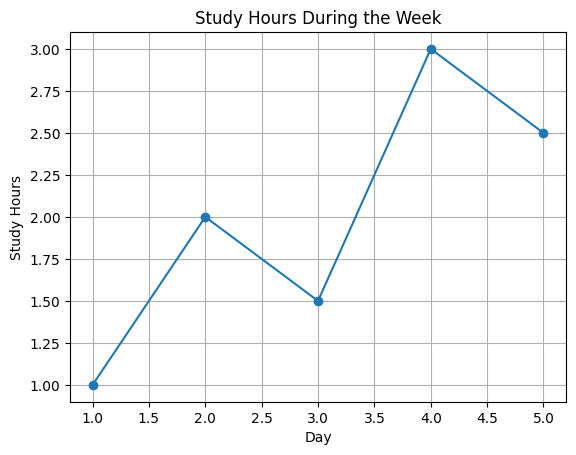

In [12]:
import matplotlib.pyplot as plt

days = [1, 2, 3, 4, 5]
study_hours_per_day = [1, 2, 1.5, 3, 2.5]

plt.plot(
    days,
    study_hours_per_day,
    marker="o"
)
plt.title("Study Hours During the Week")
plt.xlabel("Day")
plt.ylabel("Study Hours")
plt.grid(True)
plt.show()


A **line chart** is useful when the x-axis follows an order, such as days or time.


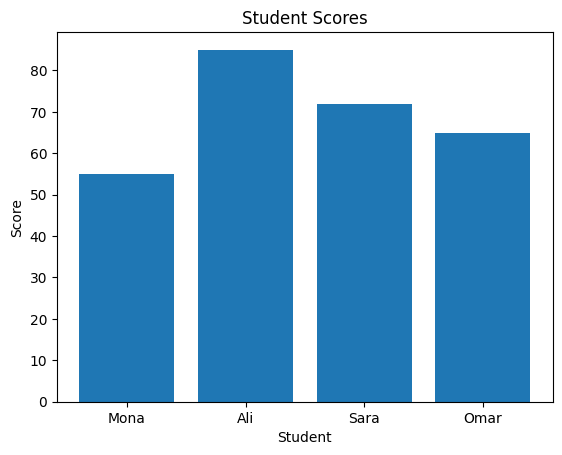

In [13]:
plt.bar(students_clean["Name"], students_clean["Score"])
plt.title("Student Scores")
plt.xlabel("Student")
plt.ylabel("Score")
plt.show()


A **bar chart** compares values across categories.


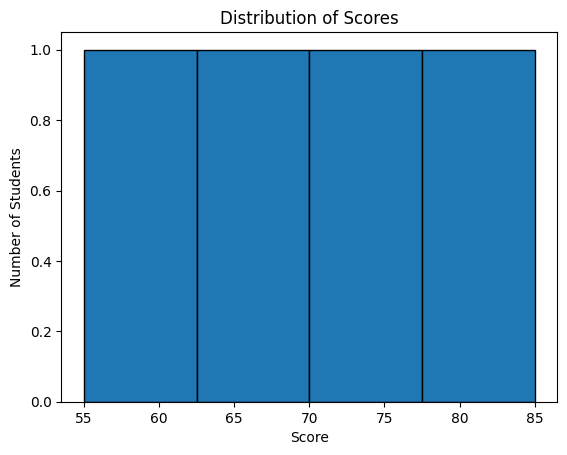

In [14]:
plt.hist(students_clean["Score"], bins=4, edgecolor="black")
plt.title("Distribution of Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.show()


A **histogram** shows the distribution of one numerical column.


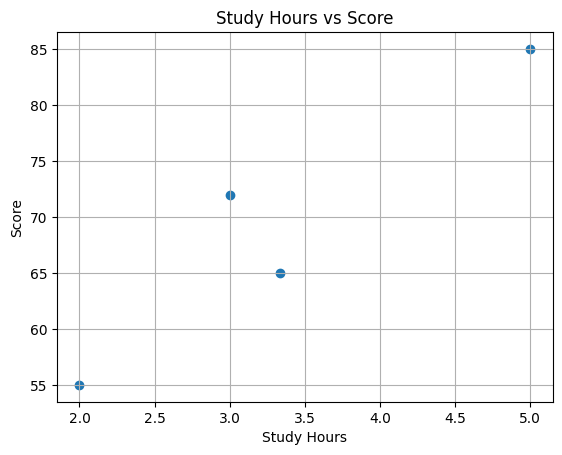

In [15]:
plt.scatter(students_clean["StudyHours"], students_clean["Score"])
plt.title("Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.grid(True)
plt.show()


A **scatter plot** shows the relationship between two numerical columns.

## Matplotlib practice

Create a bar chart showing each student's study hours. Add a title and labels for both axes.


---

# Part 4: Using the libraries on the Titanic dataset

We will now use the same three libraries on a real dataset:

- pandas loads and cleans the table;
- NumPy helps create a new column using conditions; and
- Matplotlib visualizes the results.


## Step 1: Download and load the dataset

`pd.read_csv()` can read a CSV file directly from a web address. The next cell downloads the Titanic dataset and loads it into a DataFrame, so no file upload is needed.

Dataset source: [Data Science Dojo datasets repository](https://github.com/datasciencedojo/datasets/blob/master/titanic.csv)


In [16]:
dataset_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(dataset_url)

print("Dataset downloaded and loaded successfully.")


Dataset downloaded and loaded successfully.


In [17]:
print("First five rows:\n", df.head())
print("\nLast five rows:\n", df.tail())


First five rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

## Step 2: Explore the dataset

Before changing data, check its size, columns, data types, statistics, and missing values.


In [18]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDataset information:")
df.info()


Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
print("Missing values in each column:")
df.isnull().sum()


Missing values in each column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Step 3: Clean the dataset

We will:

- fill missing `Age` values with the mean (average) age;
- fill missing `Embarked` values with the mode (most common value);
- remove the `Cabin` column because it contains many missing values;
- remove duplicate rows; and
- rename two columns.


In [21]:
mean_age = df["Age"].mean()
most_common_port = df["Embarked"].mode()[0]

df["Age"] = df["Age"].fillna(mean_age)
df["Embarked"] = df["Embarked"].fillna(most_common_port)
df = df.drop(columns=["Cabin"], errors="ignore")

print("Missing values after filling and dropping:")
df.isnull().sum()


Missing values after filling and dropping:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [22]:
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates()

df = df.rename(columns={
    "Pclass": "PassengerClass",
    "Sex": "Gender"
})

print("New column names:", df.columns.tolist())


Duplicate rows before removal: 0
New column names: ['PassengerId', 'Survived', 'PassengerClass', 'Name', 'Gender', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


## Step 4: Detect and remove fare outliers

An outlier is a value that is far from most other values. Here we use the interquartile range (IQR) method.

- `Q1` is the lower quartile.
- `Q3` is the upper quartile.
- `IQR = Q3 - Q1`.

This lab removes the detected fare outliers to demonstrate the method. In a real project, we should investigate outliers before deciding to remove them.


In [23]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of fare outliers:", len(outliers))

df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)].copy()
print("Shape after removing fare outliers:", df.shape)


Lower limit: -26.724
Upper limit: 65.6344
Number of fare outliers: 116
Shape after removing fare outliers: (775, 11)


## Step 5: Create new features

Feature engineering means creating useful columns from existing columns.

- `FamilySize` combines siblings/spouses, parents/children, and the passenger.
- `AgeGroup` uses `np.where()` to label passengers as Child, Adult, or Senior.


In [24]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["AgeGroup"] = np.where(
    df["Age"] < 18,
    "Child",
    np.where(df["Age"] < 60, "Adult", "Senior")
)

df[["Age", "SibSp", "Parch", "FamilySize", "AgeGroup"]].head()


,Age,SibSp,Parch,FamilySize,AgeGroup
0,22.000000,1,0,2,Adult
2,26.000000,0,0,1,Adult
3,35.000000,1,0,2,Adult
4,35.000000,0,0,1,Adult
5,29.699118,0,0,1,Adult


## Step 6: Filter and group the data


In [25]:
passengers_over_30 = df[df["Age"] > 30]
men_over_30 = df[(df["Age"] > 30) & (df["Gender"] == "male")]

print("Passengers over 30:", len(passengers_over_30))
print("Male passengers over 30:", len(men_over_30))
print("\nExample rows:\n", men_over_30.head())


Passengers over 30: 248
Male passengers over 30: 181

Example rows:
     PassengerId  Survived  PassengerClass                         Name Gender  \
4             5         0               3     Allen, Mr. William Henry   male   
6             7         0               1      McCarthy, Mr. Timothy J   male   
13           14         0               3  Andersson, Mr. Anders Johan   male   
20           21         0               2         Fynney, Mr. Joseph J   male   
21           22         1               2        Beesley, Mr. Lawrence   male   

     Age  SibSp  Parch  Ticket     Fare Embarked  FamilySize AgeGroup  
4   35.0      0      0  373450   8.0500        S           1    Adult  
6   54.0      0      0   17463  51.8625        S           1    Adult  
13  39.0      1      5  347082  31.2750        S           7    Adult  
20  35.0      0      0  239865  26.0000        S           1    Adult  
21  34.0      0      0  248698  13.0000        S           1    Adult  


In [26]:
print("Survival rate by gender:")
print(df.groupby("Gender")["Survived"].mean())

print("\nAverage fare by passenger class:")
print(df.groupby("PassengerClass")["Fare"].mean())

print("\nNumber of passengers in each class:")
print(df.groupby("PassengerClass")["PassengerId"].count())


Survival rate by gender:
Gender
female    0.688525
male      0.178908
Name: Survived, dtype: float64

Average fare by passenger class:
PassengerClass
1    37.052978
2    19.186266
3    12.867449
Name: Fare, dtype: float64

Number of passengers in each class:
PassengerClass
1    112
2    179
3    484
Name: PassengerId, dtype: int64


## Step 7: Visualize the data

The following cells use the same chart types introduced earlier.


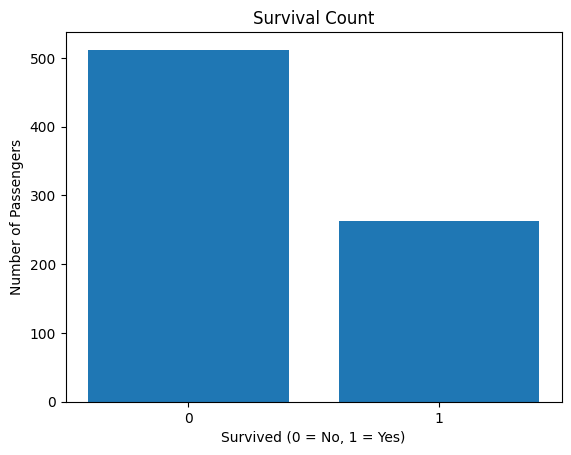

In [27]:
survival_counts = df["Survived"].value_counts().sort_index()

plt.bar(survival_counts.index.astype(str), survival_counts.values)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


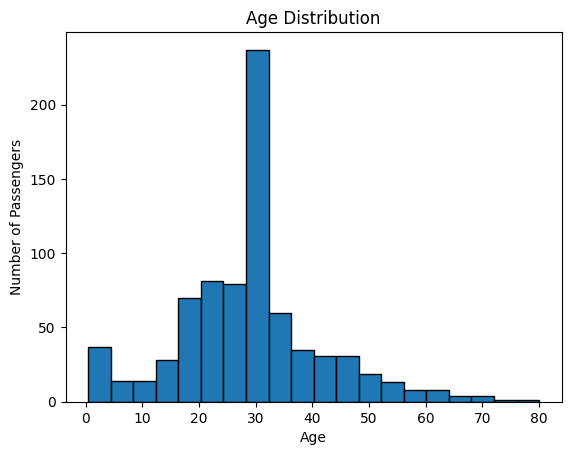

In [28]:
plt.hist(df["Age"], bins=20, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


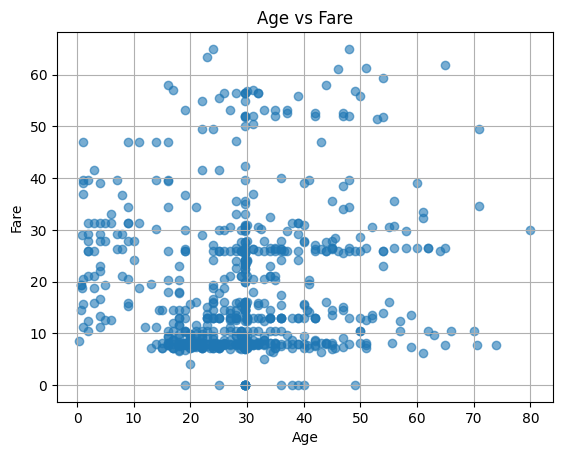

In [29]:
plt.scatter(df["Age"], df["Fare"], alpha=0.6)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.grid(True)
plt.show()


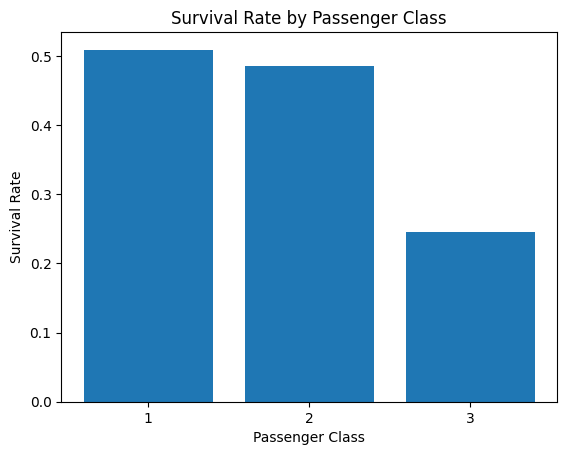

In [30]:
survival_by_class = df.groupby("PassengerClass")["Survived"].mean()

plt.bar(
    survival_by_class.index.astype(str),
    survival_by_class.values
)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


# Lab summary

In this lab, you:

- converted Python lists to NumPy arrays;
- used NumPy for calculations, conditions, and two-dimensional data;
- created and inspected pandas DataFrames;
- selected, filtered, cleaned, and grouped data;
- converted pandas columns to a NumPy array;
- created four common Matplotlib charts; and
- applied all three libraries to the Titanic dataset.

## Final practice

Choose any **two** tasks during the lab. The remaining tasks are optional practice.

1. Find the average age of the cleaned passengers.
2. Count passengers in each `AgeGroup`.
3. Filter passengers whose fare is greater than the average fare.
4. Create a bar chart showing the number of passengers in each `AgeGroup`.
5. Create a scatter plot of `FamilySize` and `Fare`.
